# Desafio 3 - Gurmendi Alan

## Consigna

- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


---

In [2]:
import random
import io
import pickle
import json
import bs4 as bs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical, pad_sequences
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout, GRU
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

2025-11-26 17:01:26.333876: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-26 17:01:26.337941: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-26 17:01:26.544914: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-26 17:01:27.698296: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

### Seleccion del dataset y preprocesamiento

Para entrenar el modelo se va a utilizar el libro "Veinte mil leguas de viaje submarino" de Julio Verne

Se descarga el libro

In [4]:
raw_html = urllib.request.urlopen('https://www.textos.info/julio-verne/veinte-mil-leguas-de-viaje-submarino/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [5]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

' el año 1866 quedó caracterizado por un extraño acontecimiento, por un\n fenómeno inexplicable e inexplicado que nadie, sin duda, ha podido \nolvidar. sin hablar de los rumores que agitaban a las poblaciones de los\n puertos y que sobreexcitaban a los habitantes del interior de los \ncontinentes, el misterioso fenómeno suscitó una particular emoción entre\n los hombres del mar. negociantes, armadores, capitanes de barco, \nskippers y masters de europa y de américa, oficiales de la marina de \nguerra de todos los países y, tras ellos, los gobiernos de los \ndiferentes estados de los dos continentes, manifestaron la mayor \npreocupación por el hecho. desde hacía algún tiempo, en efecto, varios barcos se habían \nencontrado en sus derroteros con «una cosa enorme», con un objeto largo,\n fusiforme, fosforescente en ocasiones, infinitamente más grande y más \nrápido que una ballena. los hechos relativos a estas apariciones, consignados en los \ndiferentes libros de a bordo, coincidían con 

Se define un contexto de 100 palabras

In [6]:
# seleccionamos el tamaño de contexto
max_context_size = 100

Se arma el vocabulario como el conjunto de caracteres unicos que hay en libro. Se lo ordena para que ante diferentes ejecuciones de la notebook se mantenga siempre el mismo.

In [7]:
chars_vocab = sorted(set(article_text))  # orden fijo

In [8]:
len(chars_vocab)

67

In [7]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

In [8]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [9]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [10]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text   = tokenized_text[-num_val*max_context_size:]

In [11]:
tokenized_sentences_val = [
    val_text[init*max_context_size : (init+1)*max_context_size]
    for init in range(num_val)
]

In [12]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [13]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

In [14]:
vocab_size = len(chars_vocab)

### Creacion de los modelos

Hacemos 2 modelos, uno con GRU y otro con SimpleRNN

In [67]:
model_gru = Sequential()

model_gru.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model_gru.add(GRU(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model_gru.add(Dense(vocab_size, activation='softmax'))
model_gru.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model_gru.summary()

/home/alan/Escritorio/proyectos/PLN/venv/lib/python3.12/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, None, 67)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, None, 200)      │       161,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 67)       │        13,467 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,867 (683.07 KB)

 Trainable params: 174,867 (683.07 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
model_simple_rnn = Sequential()

model_simple_rnn.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model_simple_rnn.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model_simple_rnn.add(Dense(vocab_size, activation='softmax'))
model_simple_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model_simple_rnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_3              │ (None, None, 67)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 200)      │        53,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, None, 67)       │        13,467 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,067 (261.98 KB)

 Trainable params: 67,067 (261.98 KB)

 Non-trainable params: 0 (0.00 B)

El callback original provisto por la cátedra generaba problemas de memoria al entrenar el modelo con GRU, lo que provocaba que al finalizar el primer epoch la computadora se congelara. Para resolverlo, se realizaron ajustes que reducen la cantidad de subsecuencias evaluadas y evitan la creación de estructuras de datos demasiado grandes, reordenando el cálculo de la perplejidad para hacerlo más eficiente. Estos cambios preservan la lógica del callback original pero permiten ejecutar el entrenamiento sin fallos. Para implementarlos y validar el enfoque se utilizó ChatGPT como apoyo.

In [69]:
class PplCallback(keras.callbacks.Callback):
    '''
    Mismo objetivo que el callback provisto:
    - Calcula perplejidad en validación al final de cada epoch
    - Hace early stopping con paciencia `patience`
    Pero procesa las predicciones en batches para no explotar memoria.
    '''

    def __init__(self, val_data, history_ppl,model_name, max_context_size, patience=5, batch_size=256):
        super().__init__()
        self.val_data = val_data
        self.history_ppl = history_ppl
        self.patience = patience
        self.batch_size = batch_size
        self.max_context_size = max_context_size
        self.model_name = model_name

        self.target = []
        padded_list = []
        self.info = []           # (start_idx, end_idx) por secuencia
        count = 0

        # Construimos subsecuencias + targets
        for seq in self.val_data:
            len_seq = len(seq)
            # subsecuencias prefijo: seq[:1], seq[:2], ..., seq[:len_seq-1]
            subseq = [seq[:i] for i in range(1, len_seq)]
            self.target.extend([seq[i] for i in range(1, len_seq)])

            if len(subseq) != 0:
                padded_seq = pad_sequences(
                    subseq,
                    maxlen=self.max_context_size,
                    padding='pre'
                )
                padded_list.append(padded_seq)
                # guardamos rango de índices globales para esta secuencia
                # OJO: usamos len(subseq), no len_seq, para ser consistentes
                start = count
                end   = count + len(subseq)
                self.info.append((start, end))
                count = end

        # Apilamos todas las subsecuencias paddeadas
        self.padded = np.vstack(padded_list)

        # Mapeo de índice de subsecuencia -> índice de secuencia original
        self.num_seqs = len(self.info)
        self.seq_for_idx = np.empty(len(self.padded), dtype=np.int32)
        for seq_id, (start, end) in enumerate(self.info):
            self.seq_for_idx[start:end] = seq_id

        # Para early stopping
        self.min_score = np.inf
        self.patience_counter = 0

        print(f"[PplCallback] padded shape: {self.padded.shape}, num_val_seqs: {self.num_seqs}")

    def on_epoch_end(self, epoch, logs=None):
        # Acumuladores por secuencia
        logprob_sum = np.zeros(self.num_seqs, dtype=np.float64)
        count_tok   = np.zeros(self.num_seqs, dtype=np.int64)

        N = len(self.padded)
        # Recorremos self.padded en batches
        for start_idx in range(0, N, self.batch_size):
            end_idx = min(start_idx + self.batch_size, N)
            xb = self.padded[start_idx:end_idx]

            # Predicciones para este batch
            preds = self.model(xb, training=False).numpy()  # shape: (B, T, vocab)

            # Usamos SOLO el último timestep como en el callback original
            preds_last = preds[:, -1, :]  # shape: (B, vocab_size)

            # Índices globales de subsecuencia para este batch
            global_idx = np.arange(start_idx, end_idx)
            # tokens target correspondientes
            target_batch = np.array(self.target[start_idx:end_idx], dtype=np.int32)
            # secuencia original a la que pertenece cada subsecuencia
            seq_ids = self.seq_for_idx[global_idx]

            # Probabilidades de los tokens target
            probs = preds_last[np.arange(len(target_batch)), target_batch]
            # Evitamos log(0)
            probs = np.clip(probs, 1e-12, 1.0)

            # Acumulamos log-probabilidad por secuencia
            np.add.at(logprob_sum, seq_ids, np.log(probs))
            np.add.at(count_tok,   seq_ids, 1)

        # Calculamos perplejidad por secuencia y promedio
        scores = []
        for s in range(self.num_seqs):
            if count_tok[s] > 0:
                avg_logprob = logprob_sum[s] / count_tok[s]
                scores.append(np.exp(-avg_logprob))

        current_score = float(np.mean(scores))
        self.history_ppl.append(current_score)
        print(f"\n mean perplexity: {current_score:.4f} \n")

        # Early stopping igual que antes
        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save(f"my_model_{self.model_name}.keras")
            print("Saved new model!")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print("Stopping training...")
                self.model.stop_training = True

### Entrenamiento de los modelos

Se entrena el modelo que utiliza GRU

In [ ]:
history_ppl_gru = []

ppl_cb = PplCallback(
    val_data=tokenized_sentences_val,
    history_ppl=history_ppl_gru,
    model_name='gru',
    max_context_size=max_context_size,
    patience=3,
    batch_size=256 
)


hist_gru = model_gru.fit(
    X, y,
    epochs=20,
    batch_size=256,
    callbacks=[ppl_cb]
)

[PplCallback] padded shape: (83853, 100), num_val_seqs: 847
Epoch 1/20
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 2.2498
 mean perplexity: 5.4116 

Saved new model!
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 507s 170ms/step - loss: 2.0169
Epoch 2/20
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 1.6790
 mean perplexity: 4.6005 

Saved new model!
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 508s 171ms/step - loss: 1.6331
Epoch 3/20
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 1.5405
 mean perplexity: 4.3688 

Saved new model!
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 507s 171ms/step - loss: 1.5228
Epoch 4/20
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 1.4814
 mean perplexity: 4.2625 

Saved new model!
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 508s 171ms/step - loss: 1.4714
Epoch 5/20
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 1.4456
 mean perplexity: 4.2168 

Saved new model!
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 509s 171ms/step - loss: 1.4400
Epoch 6/20
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step

Se observa la gráfica de como disminuye la perplejidad a medida que avanza el entrenamiento

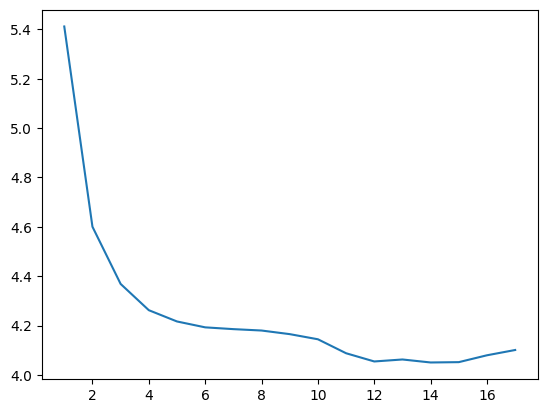

In [ ]:
epoch_count = range(1, len(history_ppl_gru) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl_gru)
plt.show()

Se guardan los resultados obtenidos en el entrenamiento

In [ ]:
with open("modelos_desafio_3/history_ppl.json", "w") as f:
    json.dump(history_ppl_gru, f)

Se entrena el modelo que utiliza SimpleRNN

In [ ]:
history_ppl_srnn = []

ppl_cb = PplCallback(
    val_data=tokenized_sentences_val,
    history_ppl=history_ppl_srnn,
    model_name='simple_rnn',
    max_context_size=max_context_size,
    patience=3,
    batch_size=256
)


hist_srnn= model_simple_rnn.fit(
    X, y,
    epochs=20,
    batch_size=256,
    callbacks=[ppl_cb]
)

[PplCallback] padded shape: (83853, 100), num_val_seqs: 847
Epoch 1/20
2974/2975 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 2.2862
 mean perplexity: 5.7166 

Saved new model!
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 251s 84ms/step - loss: 2.0715
Epoch 2/20
2974/2975 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 1.8488
 mean perplexity: 5.2118 

Saved new model!
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 250s 84ms/step - loss: 1.8275
Epoch 3/20
2974/2975 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 1.7840
 mean perplexity: 5.0554 

Saved new model!
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 249s 84ms/step - loss: 1.7758
Epoch 4/20
2974/2975 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 1.7560
 mean perplexity: 4.9451 

Saved new model!
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 250s 84ms/step - loss: 1.7510
Epoch 5/20
2974/2975 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 1.7386
 mean perplexity: 4.8980 

Saved new model!
2975/2975 ━━━━━━━━━━━━━━━━━━━━ 250s 84ms/step - loss: 1.7353
Epoch 6/20
2974/2975 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 1.

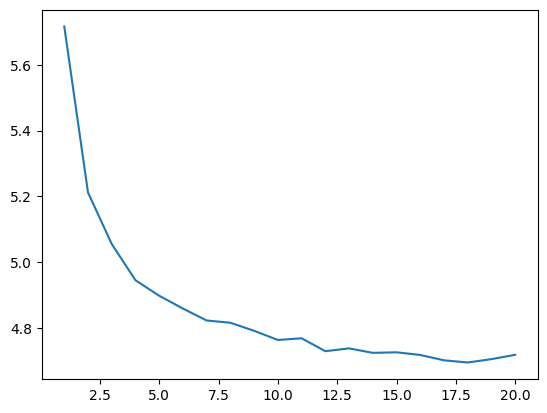

In [77]:
# Entrenamiento
epoch_count = range(1, len(history_ppl_srnn) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl_srnn)
plt.show()

Se guardan los resultados obtenidos en el entrenamiento


In [ ]:
with open("modelos_desafio_3/history_ppl_simple_rnn.json", "w") as f:
    json.dump(history_ppl_srnn, f)

En primer lugar, se observa una diferencia clara en los tiempos de entrenamiento entre ambos modelos. El modelo basado en GRU requirió aproximadamente 164 minutos, mientras que la versión con SimpleRNN tardó cerca de 50 minutos. Esto se debe a que una unidad GRU incorpora más parámetros y operaciones internas que una celda SimpleRNN, lo cual incrementa el costo computacional por epoch.

Por otro lado, el modelo con GRU no solo entrenó durante menos epochs, sino que también alcanzó una métrica de perplejidad superior. La perplejidad final fue de 4.10 en la epoch 17, mientras que el modelo SimpleRNN obtuvo un valor de 4.72 recién al completar las 20 epochs. Esta diferencia indica que la arquitectura GRU logra capturar mejor el contexto y generar predicciones más precisas.

### Evaluacion de los modelos

In [ ]:
# Cargamos los mejores modelos guardados durante el entrenamiento
model_gru = keras.models.load_model('modelos_desafio_3/my_model_gru.keras')
model_simple_rnn = keras.models.load_model('modelos_desafio_3/my_model_simple_rnn.keras')

2025-11-26 15:07:22.585962: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-11-26 15:07:22.586416: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-11-26 15:07:22.586425: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: alan-ASUS-TUF-Gaming-A15-FA507UI-FA507UI
2025-11-26 15:07:22.586436: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] hostname: alan-ASUS-TUF-Gaming-A15-FA507UI-FA507UI
2025-11-26 15:07:22.586729: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:190] libcuda reported version is: 575.64.3
2025-11-26 15:07:22.586750: I external/local_xla/xla/s

#### Se definen las funciones que se van a utilizar para probar los modelos

In [16]:
def greedy_search(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [17]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [18]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

#### Se realizar pruebas sobre ambos modelos con diferentes casos y combinaciones


Para todos los casos se va a utilizart el siguiente texto como input y se va a esperar que devuelvan un total de 100 caracteres

In [22]:
input_text='el nautilus avanzaba en silencio'

### Prueba de Greedy Search

In [25]:
greedy_search(model_simple_rnn, input_text, max_length=max_context_size, n_words=100)

'el nautilus avanzaba en silencio de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la cabeza de la ca'

In [26]:
greedy_search(model_gru, input_text, max_length=max_context_size, n_words=100)

'el nautilus avanzaba en silencio de la \nprofundidad de la costa de la costa de la costa de la costa de la costa de la \nprofundidad d'

En ambos casos se observa que la generación cae rápidamente en un loop repetitivo, lo cual es esperable dado el funcionamiento de greedy search que siempre elige el caracter más probable y no explora alternativas. Aun así, el modelo basado en GRU muestra algo más de variedad y construye frases ligeramente más coherentes, mientras que el SimpleRNN converge casi de inmediato a repeticiones muy simples.

#### Prueba de Beam Search con 3 beams y modo deterministico

In [28]:
salidas = beam_search(model_simple_rnn,num_beams=3,num_words=100,input=input_text,temp=1,mode='det')
decode(salidas[0])

'el nautilus avanzaba en silencio de los mares de los mares de los mares de los mares de los mares de los mares de los mares de los m'

In [29]:
salidas = beam_search(model_gru,num_beams=3,num_words=100,input=input_text,temp=1,mode='det')
decode(salidas[0])

'el nautilus avanzaba en silencio de los mares del \ncapitán nemo. el capitán nemo se hallaba en las aguas del capitán nemo. el capitá'

En esta prueba se observa que el SimpleRNN continúa generando repeticiones, aunque con una estructura algo más estable que en greedy search. El método logra explorar algunas alternativas, pero el modelo sigue tendiendo a secuencias muy frecuentes, por lo que la repetición persiste.Por otra parte, el modelo basado en GRU produce resultados más coherentes y cercanos al estilo del texto original, formando oraciones más completas y manteniendo mejor el contexto, aunque aún aparecen repeticiones moderadas.

#### Prueba de Beam Search con 10 beams y modo deterministico

In [30]:
salidas = beam_search(model_simple_rnn,num_beams=10,num_words=100,input=input_text,temp=1,mode='det')
decode(salidas[0])

'el nautilus avanzaba en silencio del capitán nemo el capitán nemo el capitán nemo el capitán nemo el capitán nemo el capitán nemo no'

In [31]:
salidas = beam_search(model_gru,num_beams=10,num_words=100,input=input_text,temp=1,mode='det')
decode(salidas[0])

'el nautilus avanzaba en silencio. el capitán nemo me preguntó el capitán nemo. el capitán nemo me preguntó el capitán nemo se había '

En este caso, el SimpleRNN sigue mostrando un comportamiento fuertemente repetitivo, generando secuencias largas con la misma frase una y otra vez. Aunque el método evalúa más alternativas, el modelo tiende igualmente a elegir continuaciones muy frecuentes. Por su parte, el modelo basado en GRU continúa produciendo texto más coherente y con oraciones mejor formadas, aunque también aparece cierta repetición de patrones comunes. Aun así, el resultado es claramente más legible que el obtenido con el SimpleRNN.

#### Prueba de Beam Search con 5 beams, modo estocastico y temperatura de 0.7

In [32]:
salidas = beam_search(model_simple_rnn,num_beams=5,num_words=100,input=input_text,temp=0.7,mode='sto')
decode(salidas[0])

'el nautilus avanzaba en silencio de los mares de los que se había de la corriente de los estrechos de la mano de la mañana de la mañ'

In [34]:
salidas = beam_search(model_gru,num_beams=5,num_words=100,input=input_text,temp=0.7,mode='sto')
decode(salidas[0])

'el nautilus avanzaba en silencio del nautilus. los peces del nautilus se hallaba una profundidad del \ntiempo del nautilus. el capitá'

En esta prueba, la incorporación de aleatoriedad permite que el SimpleRNN salga de los loops más rígidos y genere continuaciones algo más variadas, aunque la coherencia general sigue siendo limitada y aparecen frases desordenadas. En contraste, el modelo basado en GRU aprovecha mejor la exploración estocástica y mantiene resultados más coherentes, incorporando variedad sin perder sentido. El texto generado conserva referencias temáticas correspondientes al libro y una estructura mucho más estable que la del SimpleRNN.

#### Prueba de Beam Search con 5 beams, modo estocastico y temperatura 1.3

In [35]:
salidas = beam_search(model_simple_rnn,num_beams=5,num_words=100,input=input_text,temp=1.3,mode='sto')
decode(salidas[0])

'el nautilus avanzaba en silencio de su abraham lincoln un estaba de esos cuando a la vez que el nautilus se había que el capitán nem'

In [36]:
salidas = beam_search(model_gru,num_beams=5,num_words=100,input=input_text,temp=1.3,mode='sto')
decode(salidas[0])

'el nautilus avanzaba en silencio, en efecto, de sus \nmovimientos, el capitán nemo me atravesó en la especie del nautilus. la posició'

En este escenario, el aumento de la temperatura introduce una mayor variabilidad en las predicciones. El SimpleRNN muestra rápidamente signos de inestabilidad y produce frases desordenadas o poco coherentes, mezclando elementos del libro con construcciones gramaticales incorrectas. El modelo basado en GRU, en cambio, tolera mejor este nivel de exploración y mantiene una coherencia razonable, generando texto más fluido y aún relacionado con el estilo original, aunque también aparecen desviaciones y repeticiones moderadas.

### Conclusiones

En general, el modelo basado en GRU mostró un rendimiento claramente superior al SimpleRNN. Logró una menor perplejidad, generó texto más coherente y mantuvo mejor el estilo del libro en prácticamente todas las pruebas. El modelo basado en SimpleRNN tendió a caer en repeticiones simples y a perder coherencia rápidamente, mientras que el de GRU pudo sostener oraciones más completas.

También es importante destacar que, a pesar de tratarse de un modelo carácter a carácter, ninguno de los dos modelos falló en la construcción de palabras, lo cual indica que ambos aprendieron adecuadamente la estructura del vocabulario y la ortografía del texto original.